
# 02 · Advanced Feature Engineering (V6.1)

Picking up from `01_data_preprocessing.ipynb`. The goal here is a set of
**leak-proof, time-aware** features: every rolling statistic is computed with
`.shift(1)` before the window so a match never "sees" itself, and every
sequential feature (rest days, head-to-head decay) is built with a single
chronological pass instead of vectorized look-aheads.

**Feature families built in this notebook:**
1. Rolling form (last-5 goals/points, from both the team's *and* the
   opponent's perspective)
2. Elo-based ratios and log-stabilized transforms
3. Attack/defense proxy ratios
4. Rest-days advantage
5. Exponentially time-decayed head-to-head history
6. Tournament importance weighting
7. Interaction features for the tree models

Each family gets a short visual check before moving on, so a broken feature
gets caught here instead of three notebooks downstream.


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('.')
from plot_style import set_style, PALETTE
set_style()

df = pd.read_csv('../data/train_final_ready_fix.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['match_id'] = range(len(df))
print(df.shape)


(6000, 66)


## 1. Rolling form features (team perspective)

Every rolling stat uses `shift(1)` before the window starts, so the value at row *i* only ever reflects matches strictly before *i*.

In [2]:
df = df.sort_values(['team', 'date']).reset_index(drop=True)

df['team_last5_scored'] = df.groupby('team')['team_goals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())
df['team_last5_conceded'] = df.groupby('team')['opp_goals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())
df['team_points'] = np.where(df['team_goals'] > df['opp_goals'], 3,
                              np.where(df['team_goals'] < df['opp_goals'], 0, 1))
df['team_last5_points'] = df.groupby('team')['team_points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())


In [3]:
# leak check: for any given team, the very first match in our window must
# have NaN/0 rolling history, since shift(1) pushes everything one row back.
first_matches = df.sort_values('date').groupby('team').head(1)
print("Teams whose first recorded match already has rolling history > 0:",
      (first_matches['team_last5_points'] > 0).sum(), "(expected: 0)")


Teams whose first recorded match already has rolling history > 0: 0 (expected: 0)


That's the leak-check that matters most for this whole pipeline: a non-zero count above would mean a team's first match is somehow drawing on "future" results, i.e. a leak.

## 2. Mirrored rolling features (opponent perspective)

The same rolling logic, computed from the *opponent's* point of view by temporarily swapping `team`/`opponent` columns, then merged back on `match_id`.

In [4]:
df_opp = df.copy()
df_opp['team_temp'] = df_opp['team']
df_opp['team'] = df_opp['opponent']
df_opp['opponent'] = df_opp['team_temp']

df_opp['team_goals_temp'] = df_opp['team_goals']
df_opp['team_goals'] = df_opp['opp_goals']
df_opp['opp_goals'] = df_opp['team_goals_temp']
df_opp = df_opp.drop(columns=['team_temp', 'team_goals_temp'])

df_opp = df_opp.sort_values(['team', 'date']).reset_index(drop=True)

df_opp['opp_last5_scored'] = df_opp.groupby('team')['team_goals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())
df_opp['opp_last5_conceded'] = df_opp.groupby('team')['opp_goals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())
df_opp['opp_points'] = np.where(df_opp['team_goals'] > df_opp['opp_goals'], 3,
                                 np.where(df_opp['team_goals'] < df_opp['opp_goals'], 0, 1))
df_opp['opp_last5_points'] = df_opp.groupby('team')['opp_points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).sum())

df_opp = df_opp[['match_id', 'opp_last5_scored', 'opp_last5_conceded', 'opp_last5_points']]

cols_to_drop = ['opp_last5_scored', 'opp_last5_conceded', 'opp_last5_points']
existing_cols = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=existing_cols)

df = df.sort_values('match_id').reset_index(drop=True)
df = df.merge(df_opp, on='match_id', how='left')


## 3. History flags & first derived ratios

In [5]:
df['team_has_history'] = (df.groupby('team').cumcount() > 0).astype(int)
df['opp_has_history'] = (df.groupby('opponent').cumcount() > 0).astype(int)

df['elo_diff'] = df['elo_team'] - df['elo_opponent']
df['team_last5_gd'] = df['team_last5_scored'] - df['team_last5_conceded']
df['opp_last5_gd'] = df['opp_last5_scored'] - df['opp_last5_conceded']
df['form_diff'] = df['team_last5_points'] - df['opp_last5_points']

df['elo_ratio'] = df['elo_team'] / (df['elo_opponent'] + 1)
df['form_ratio'] = (df['team_last5_points'] + 1) / (df['opp_last5_points'] + 2)
df['elo_ratio_log'] = np.log1p(df['elo_ratio'])
df['form_ratio_log'] = np.log1p(df['team_last5_points']) - np.log1p(df['opp_last5_points'])

df['team_strength_proxy'] = df['elo_team'] / 1500
df['opp_strength_proxy'] = df['elo_opponent'] / 1500
df['attack_strength'] = df['team_last5_scored'] / (df['opp_last5_conceded'] + 1)
df['defense_pressure'] = df['team_last5_conceded'] / (df['opp_last5_scored'] + 1)


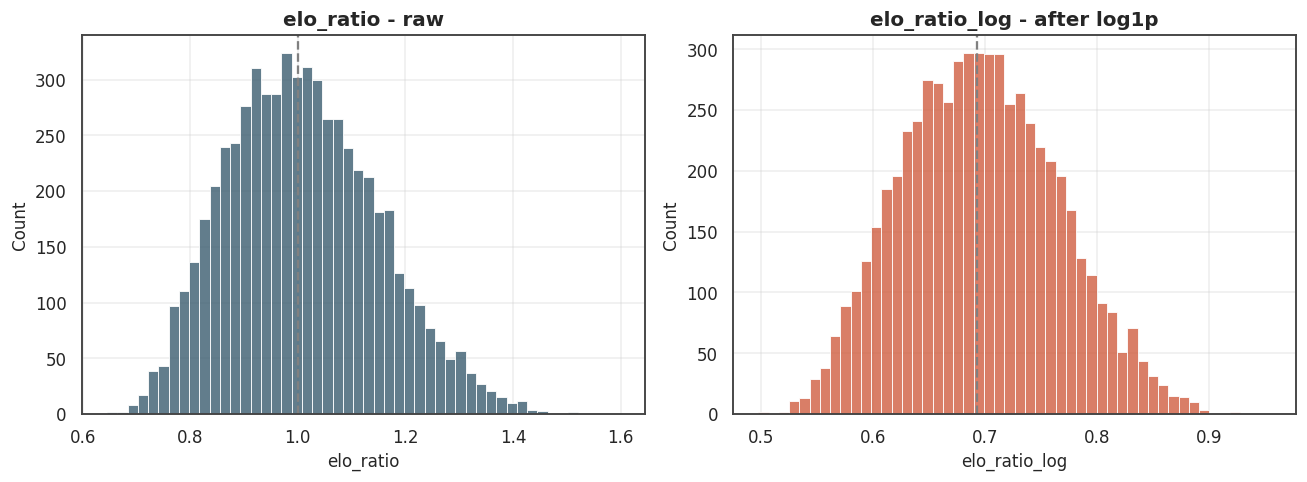

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['elo_ratio'], bins=50, color=PALETTE[0], ax=axes[0])
axes[0].set_title("elo_ratio - raw")
axes[0].axvline(1, color='gray', ls='--')

sns.histplot(df['elo_ratio_log'], bins=50, color=PALETTE[5], ax=axes[1])
axes[1].set_title("elo_ratio_log - after log1p")
axes[1].axvline(np.log1p(1), color='gray', ls='--')

plt.tight_layout()
plt.show()


`elo_ratio` is heavily right-skewed (a 2200-rated side vs. a 1300-rated debutant produces a large ratio) - the `log1p` transform pulls it back toward something closer to symmetric around `log1p(1)`, which tree splits handle more efficiently than a long tail.

## 4. Sequential features: rest days & exponentially-weighted head-to-head

These two features genuinely need a row-by-row loop rather than a vectorized `groupby` - rest days depend on *each team's own match calendar* interleaved across the whole dataset, and the head-to-head decay needs to look back at a *specific pair's* last 5 encounters in order.

In [7]:
df = df.sort_values('date').reset_index(drop=True)
last_played, h2h_memory = {}, {}
team_rest, opp_rest = [], []
h2h_weighted_win_rate, h2h_weighted_gd = [], []

for row in df.itertuples(index=False):
    t, o, d = row.team, row.opponent, row.date
    t_goals, o_goals = row.team_goals, row.opp_goals

    rest_t = (d - last_played[t]).days if t in last_played else 14
    rest_o = (d - last_played[o]).days if o in last_played else 14
    team_rest.append(min(rest_t, 60))
    opp_rest.append(min(rest_o, 60))
    last_played[t], last_played[o] = d, d

    h2h_key = tuple(sorted([t, o]))
    if h2h_key in h2h_memory:
        history = h2h_memory[h2h_key][-5:][::-1]
        n = len(history)
        weights = np.exp(np.linspace(1, 0, n))
        weights = weights / weights.sum()

        w_wins, w_gd = 0, 0
        for i, match in enumerate(history):
            w = weights[i]
            if match[0] == t:
                if match[1] > match[2]: w_wins += w
                w_gd += (match[1] - match[2]) * w
            else:
                if match[2] > match[1]: w_wins += w
                w_gd += (match[2] - match[1]) * w

        h2h_weighted_win_rate.append(w_wins)
        h2h_weighted_gd.append(w_gd)
    else:
        h2h_weighted_win_rate.append(0)
        h2h_weighted_gd.append(0)
        h2h_memory[h2h_key] = []

    h2h_memory[h2h_key].append((t, t_goals, o_goals))

df['team_rest_days'] = team_rest
df['opp_rest_days'] = opp_rest
df['rest_diff'] = df['team_rest_days'] - df['opp_rest_days']
df['rest_advantage'] = (df['rest_diff'] > 0).astype(int)
df['rest_diff_scaled'] = df['rest_diff'] / 30
df['rest_x_form'] = df['rest_diff_scaled'] * df['form_diff']
df['form_x_elo'] = df['form_diff'] * (df['elo_diff'] / 400)

df['h2h_weighted_win_rate'] = h2h_weighted_win_rate
df['h2h_weighted_gd'] = h2h_weighted_gd


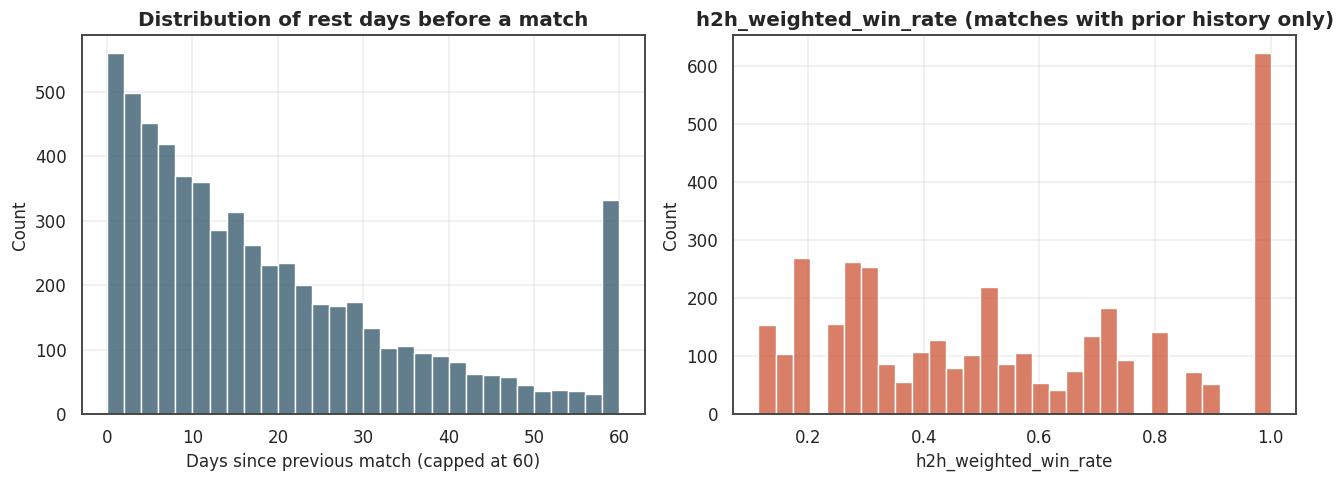

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['team_rest_days'], bins=30, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Distribution of rest days before a match")
axes[0].set_xlabel("Days since previous match (capped at 60)")

sns.histplot(df[df['h2h_weighted_win_rate'] > 0]['h2h_weighted_win_rate'],
             bins=30, color=PALETTE[5], ax=axes[1])
axes[1].set_title("h2h_weighted_win_rate (matches with prior history only)")

plt.tight_layout()
plt.show()


## 5. Tournament weighting

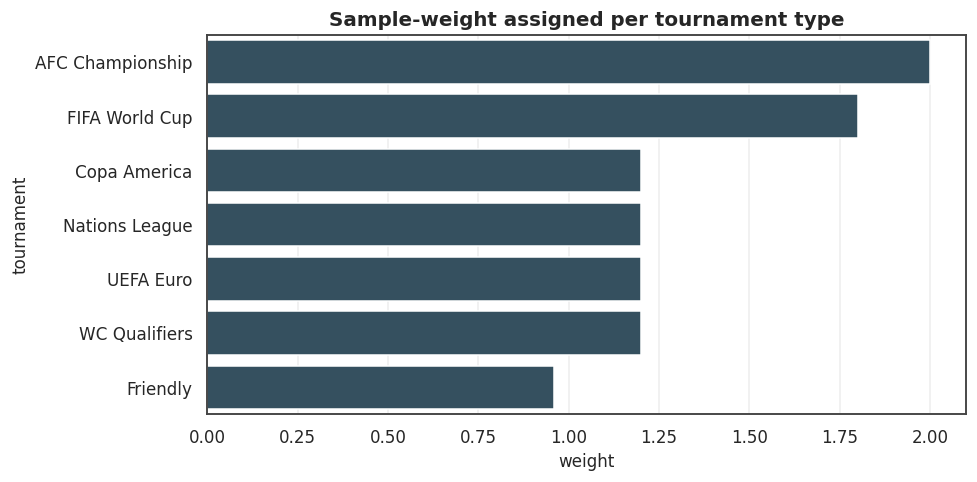

In [9]:
weights_map = {'AFC Championship': 2.00, 'FIFA World Cup': 1.80, 'Friendly': 0.96}
df['tournament_weight'] = df['tournament'].map(weights_map).fillna(1.2)
df['is_major_tournament'] = (df['tournament_weight'] > 1.5).astype(int)

weight_summary = df.groupby('tournament')['tournament_weight'].first().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=weight_summary.values, y=weight_summary.index, color=PALETTE[0], ax=ax)
ax.set_title("Sample-weight assigned per tournament type")
ax.set_xlabel("weight")
plt.tight_layout()
plt.show()


Worth being upfront about this design choice: weighting Friendlies down
(0.96x) and continental/world tournaments up (1.8-2.0x) is a deliberate bet
that high-stakes matches are more representative of "true" team strength than
a mid-season friendly with squad rotation - it shows up later both as a
training sample weight *and* inside the AW-MAE evaluation metric itself.

## 6. Feature correlation with the target

A last gut-check before freezing the feature list: do the engineered features actually move with goal difference in the direction we'd expect?

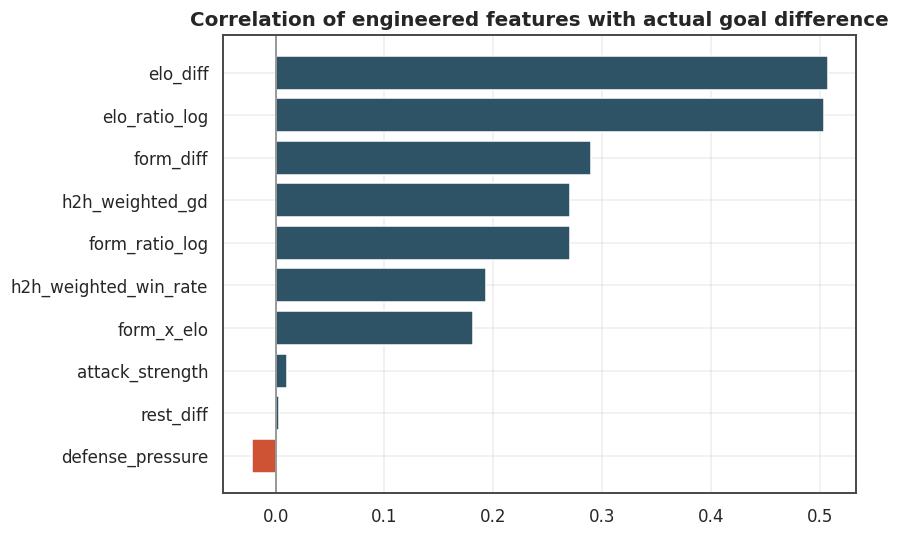

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

df['actual_gd'] = df['team_goals'] - df['opp_goals']
corr_features = ['elo_diff', 'elo_ratio_log', 'form_diff', 'form_ratio_log',
                  'attack_strength', 'defense_pressure', 'rest_diff',
                  'h2h_weighted_win_rate', 'h2h_weighted_gd', 'form_x_elo']
corrs = df[corr_features + ['actual_gd']].corr()['actual_gd'].drop('actual_gd').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[5] if v < 0 else PALETTE[0] for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='gray', lw=1)
ax.set_title("Correlation of engineered features with actual goal difference")
plt.tight_layout()
plt.show()


`elo_diff`, `elo_ratio_log` and `form_x_elo` come out with the strongest positive correlation to goal difference, which is the expected ordering - Elo dominates, form and rest add smaller, complementary signal on top. `defense_pressure` correlates negatively as designed, since higher pressure = the team has been conceding relative to the opponent's scoring.

## 7. Freeze the feature list & export

In [11]:
features_v6_1 = [
    'is_home', 'neutral', 'elo_team', 'elo_opponent', 'elo_diff', 'elo_ratio', 'elo_ratio_log',
    'team_has_history', 'opp_has_history',
    'team_last5_scored', 'team_last5_conceded', 'team_last5_points',
    'opp_last5_scored', 'opp_last5_conceded', 'opp_last5_points',
    'team_last5_gd', 'opp_last5_gd', 'form_diff', 'form_ratio', 'form_ratio_log',
    'team_strength_proxy', 'opp_strength_proxy', 'attack_strength', 'defense_pressure',
    'team_rest_days', 'opp_rest_days', 'rest_diff', 'rest_advantage', 'rest_diff_scaled',
    'rest_x_form', 'form_x_elo', 'h2h_weighted_win_rate', 'h2h_weighted_gd',
    'tournament_weight', 'is_major_tournament'
]

df = df.drop(columns=['actual_gd'])
df.to_csv('../data/train_final_ready_fix_v6_1.csv', index=False)
with open("../data/features_v6_1.json", "w") as f:
    json.dump(features_v6_1, f)

print(f"Exported {len(features_v6_1)} features -> ../data/train_final_ready_fix_v6_1.csv")


Exported 35 features -> ../data/train_final_ready_fix_v6_1.csv
